# Vasicek Model

The Vasicek model is a one-factor short-rate model used to describe the evolution of interest rates. Introduced by Oldřich Vašíček in 1977, it provides an analytically tractable framework for pricing fixed-income securities by modeling the instantaneous short rate as a mean-reverting stochastic process.

## 1. Fundamental Assumptions (Model Hypotheses)

The model rests on several idealized assumptions to maintain analytical tractability:

* **Single Risk Factor:** The short rate is the only stochastic driver of interest rates.
* **Mean Reversion:** The short rate tends to drift toward a long-term level over time.
* **Normal Distribution:** The instantaneous short rate follows a Gaussian diffusion, allowing negative rates in theory.
* **Constant Parameters:** Mean reversion speed, long-term mean, and volatility are constant.
* **Frictionless Market:** No transaction costs, taxes, or trading restrictions, and a constant risk-free pricing kernel.

## 2. Key Model Parameters

To specify the Vasicek model, the following quantities are required:

1. $r_t$: current short-term interest rate at time $t$.
2. $a$: speed of mean reversion, also called the adjustment coefficient.
3. $b$: long-term mean level toward which the short rate reverts.
4. $\sigma$: volatility of the short rate.
5. $T-t$: time horizon to maturity for the instrument being priced.

## 3. Mathematical Formulation

The Vasicek short-rate dynamics are defined by an Ornstein-Uhlenbeck process:

$$dr_t = a(b - r_t)dt + \sigma dW_t$$

where $W_t$ is a standard Brownian motion under the risk-neutral measure. The model implies:

* mean reversion: $a(b - r_t)$
* diffusion term: $\sigma dW_t$

Under the Vasicek model, the price at time $t$ of a zero-coupon bond maturing at $T$ is given by:

$$P(t,T) = e^{A(t,T) - B(t,T)r_t}$$

with

$$B(t,T) = \frac{1 - e^{-a(T-t)}}{a}$$

$$A(t,T) = \left( b - \frac{\sigma^{2}}{2a^{2}} \right) \left[ B(t,T) - (T-t) \right] - \frac{\sigma^{2}}{4a} B(t,T)^{2}$$

These expressions highlight the model's analytical convenience: bond prices are exponential-affine functions of the current short rate.

*Note:* The Vasicek model is widely used for educational purposes and as a starting point for more realistic interest-rate models, despite its limitation of permitting negative short rates due to the normal distribution assumption.

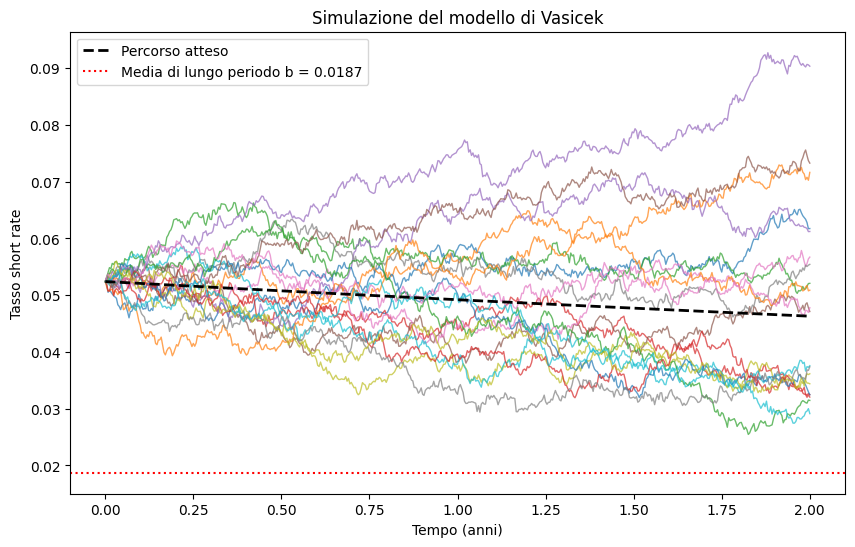

In [14]:
import numpy as np

import matplotlib.pyplot as plt

def vasicek_simulation(r0, a, b, sigma, dt, n_steps, n_paths, seed=123):
    rng = np.random.default_rng(seed)
    paths = np.empty((n_steps + 1, n_paths))
    paths[0] = r0
    sqrt_dt = np.sqrt(dt)
    for t in range(n_steps):
        dW = rng.normal(scale=sqrt_dt, size=n_paths)
        paths[t + 1] = paths[t] + a * (b - paths[t]) * dt + sigma * dW
    return paths

def vasicek_expected_path(r0, a, b, t_grid):
    return b + (r0 - b) * np.exp(-a * t_grid)

a = float(initial_params[0])
b = float(initial_params[1])
sigma = float(sigma_est)
r0 = float(r_current)

n_plot_paths = 20
paths = vasicek_simulation(r0, a, b, sigma, dt_sim, n_steps, n_plot_paths)
t_grid = np.arange(n_steps + 1) * dt_sim
expected_path = vasicek_expected_path(r0, a, b, t_grid)

fig, ax = plt.subplots(figsize=(10, 6))
for i in range(n_plot_paths):
    ax.plot(t_grid, paths[:, i], alpha=0.7, linewidth=1)
ax.plot(t_grid, expected_path, color='black', linestyle='--', linewidth=2, label='Percorso atteso')
ax.axhline(b, color='red', linestyle=':', linewidth=1.5, label=f'Media di lungo periodo b = {b:.4f}')
ax.set_title('Simulazione del modello di Vasicek')
ax.set_xlabel('Tempo (anni)')
ax.set_ylabel('Tasso short rate')
ax.legend()
plt.show()